Import Required Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import random
import matplotlib.pyplot as plt


In [ ]:
torch.__version__

'2.9.0+cu128'

In [ ]:
torchvision.__version__

'0.24.0+cu128'

In [ ]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
## Set the seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

In [ ]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP = 0.1

In [ ]:
## Define Image Transformers

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

In [ ]:
## Getting a dataset

train_dataset = datasets.CIFAR10(root="data", train= True, download= True, transform=transform)


100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


In [ ]:
test_dataset = datasets.CIFAR10(root= "data",train=False, download=True,transform=transform)


In [ ]:
## Converting our datasets into dataloaders
## Right now our data is in the form of PyTorch Datasets.

## Dataloader turns our data into batches or mini batches


In [ ]:
train_loader = DataLoader(dataset=train_dataset, batch_size= BATCH_SIZE, shuffle= True)

test_loader = DataLoader(dataset=test_dataset, batch_size = BATCH_SIZE, shuffle = False)

In [ ]:
## Building Vision Transformer Model

class PatchEmbedding(nn.Module):
  def __init__(self, img_size, patch_size, in_channels, embed_dim):
    super().__init__()
    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_channels = in_channels,
                          out_channels= embed_dim,
                          kernel_size=patch_size,
                          stride= patch_size)

    num_patches = (img_size// patch_size)**2
    self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
    self.pos_embed = nn.Parameter(torch.randn(1,1+num_patches,embed_dim))

  def forward(self, x: torch.Tensor):
    B = x.size(0) # x for example(128,3,32,32) where 128 in no of batches, 3 is input channels, 32 by 32 is size of image
    x = self.proj(x) # (B,inchannels, patch size, patch size) -> (B, no of embeddings, height/patch_size, heigh/pitch_size)
    x = x.flatten(2).transpose(1,2)
    cls_token = self.cls_token.expand(B, -1,-1)
    x = torch.cat((cls_token,x), dim=1)
    x = x+ self.pos_embed
    return x

In [ ]:
class MLP(nn.Module):
  def __init__ (self, in_features,hidden_features,drop_rate):
    super().__init__()
    self.fc1 = nn.Linear(in_features = in_features, out_features = hidden_features)

    self.fc2 = nn.Linear(in_features= hidden_features, out_features = in_features)

    self.dropout = nn.Dropout(drop_rate)

  def forward(self,x):
    x = self.dropout(F.gelu(self.fc1(x)))
    x = self.dropout(self.fc2(x))
    return x

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self,embed_dim, num_heads, mlp_dim, drop_rate):
    super().__init__()
    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = nn.MultiheadAttention(embed_dim, num_heads,dropout=drop_rate, batch_first=True)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

  def forward(self,x):
    x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
    x = x + self.mlp(self.norm2(x))
    return x

In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
    super().__init__()
    self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels,embed_dim)

    self.encoder = nn.Sequential(*[TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
    for _ in range(depth)])

    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.patch_embed(x)
    x = self.encoder(x)
    x = self.norm(x)
    cls_token = x[:,0]
    return self.head(cls_token)


In [ ]:
# Instantiate Model
model = VisionTransformer(IMAGE_SIZE,PATCH_SIZE,CHANNELS,NUM_CLASSES,
                          EMBED_DIM,DEPTH,NUM_HEADS,MLP_DIM,DROP).to(device)


In [ ]:
## Defining a Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = LEARNING_RATE)

In [ ]:
def train(model, loader, optimizer, criterion):
  # Set the mod of the model into training
  model.train()

  total_loss, correct = 0, 0

  for x, y in loader:
    x,y = x.to(device), y.to(device)
    optimizer.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()

    total_loss += loss.item() * x.size(0)
    correct+= (out.argmax(1) == y).sum().item()

  return total_loss/len(loader.dataset), correct/ len(loader.dataset)




In [ ]:
def evaluate(model,loader):
  model.eval() # Set the mode of the model to evaluation
  correct = 0
  with torch.inference_mode():
    for x,y in loader:
      x,y = x.to(device), y.to(device)
      out = model(x)
      correct+= (out.argmax(dim=1) == y).sum().item()
    return correct/ len(loader.dataset)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
### Training
train_accuracies = []
test_accuracies = []

for epoch in tqdm(range(EPOCHS)):
  train_loss, train_acc = train(model,train_loader,optimizer,criterion)
  test_acc = evaluate(model, test_loader)
  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)
  print(f"Epoch:{epoch+1}/{EPOCHS}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}%. Test acc:{test_acc:.4f}")


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch:1/10, Train loss: 1.7331, Train acc: 0.3709%. Test acc:0.4771
Epoch:2/10, Train loss: 1.3834, Train acc: 0.5039%. Test acc:0.5327
Epoch:3/10, Train loss: 1.2328, Train acc: 0.5586%. Test acc:0.5719
Epoch:4/10, Train loss: 1.1273, Train acc: 0.5966%. Test acc:0.5822
Epoch:5/10, Train loss: 1.0376, Train acc: 0.6281%. Test acc:0.6055
Epoch:6/10, Train loss: 0.9667, Train acc: 0.6536%. Test acc:0.6154
Epoch:7/10, Train loss: 0.8888, Train acc: 0.6819%. Test acc:0.6217
Epoch:8/10, Train loss: 0.8173, Train acc: 0.7090%. Test acc:0.6146
Epoch:9/10, Train loss: 0.7465, Train acc: 0.7350%. Test acc:0.6329
Epoch:10/10, Train loss: 0.6722, Train acc: 0.7597%. Test acc:0.6364


Text(0.5, 1.0, 'Training and Test Accuracy')

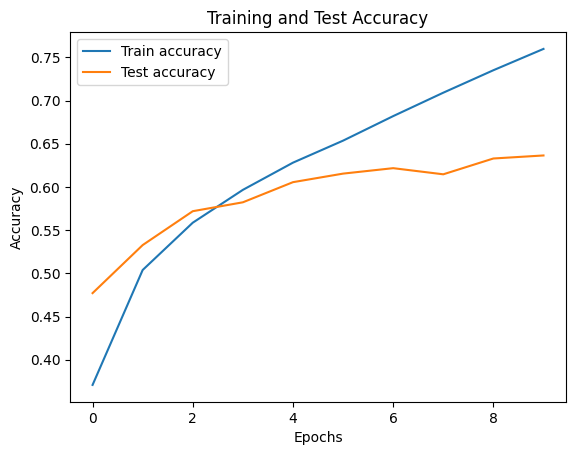

In [ ]:
plt.plot(train_accuracies, label= "Train accuracy")
plt.plot(test_accuracies, label = "Test accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Test Accuracy")

In [ ]:
import random

In [ ]:
def predict_and_plot_grid(model, dataset, classes, grid_size=3):
  model.eval()
  fig, axes = plt.subplots(grid_size, grid_size, figsize=(9,9))
  for i in range(grid_size):
    for j in range(grid_size):
      idx = random.randint(0,len(dataset)-1)
      img, true_label = dataset[idx]
      input_tensor = img.unsqueeze(dim=0).to(device)
      with torch.inference_mode():
        output = model(input_tensor)
        _,predicted = torch.max(output.data,1 )
      img = img/2 + 0.5
      npimg = img.cpu().numpy()
      axes[i,j].imshow(np.transpose(npimg, (1,2,0)))
      truth = classes[true_label] == classes[predicted.item()]
      if truth:
        color = "g"
      else:
        color = "r"

      axes[i,j].set_title(f"Truth:{classes[true_label]}\n, Predicted: {classes[predicted.item()]}",fontsize=10, c=color)
      axes[i,j].axis("off")
  plt.tight_layout()
  plt.show()







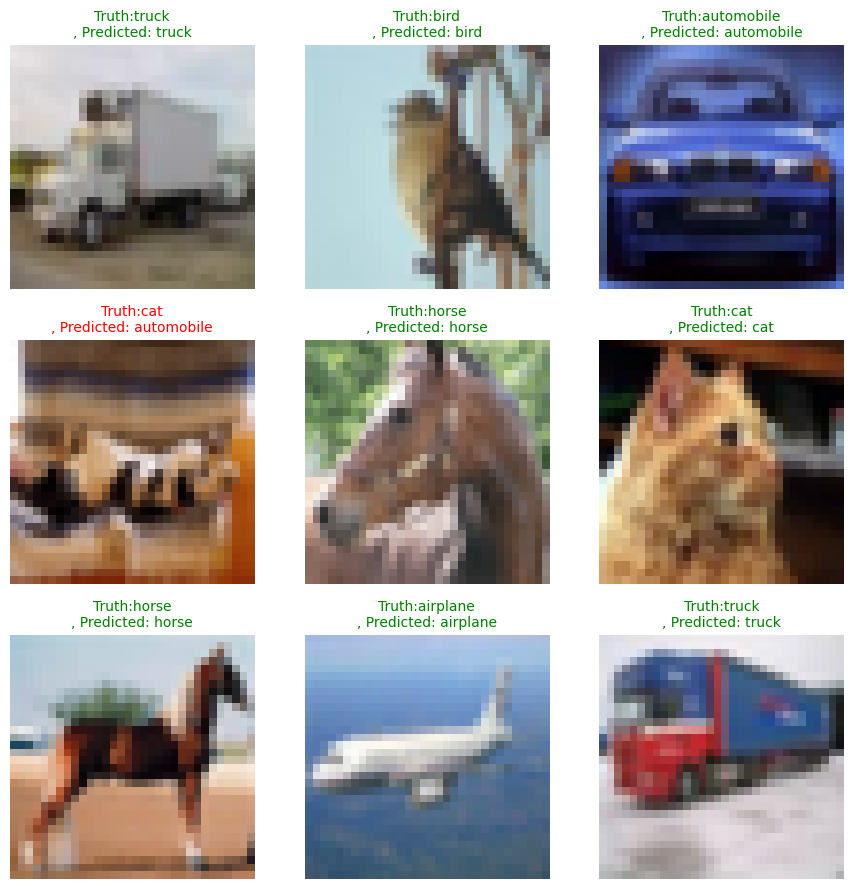

In [ ]:
predict_and_plot_grid(model, test_dataset, classes= train_dataset.classes, grid_size=3)